# 14 — GDP from monthly paths: the bridge equation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/14_gdp_bridge.ipynb)

Output is quarterly; the market is monthly. The bridge equation of the
nowcasting literature links the two: quarterly GDP growth on the quarterly
averages of monthly indicators, here payroll growth, industrial-production
growth and the change in unemployment, plus its own lag. On simulated monthly
paths each quarter's averages go through the equation and a quarterly
innovation is drawn, so eight quarters of GDP growth come out of 24 monthly
steps, with the level of output and the probability of a recession along the
paths. The parents are a block of the monthly market, SPY comes along. Needs
`statsmodels`.

Runtime: about 6 minutes.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git[garch,blocks]"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

for pkg in ("arch", "statsmodels"):
    try:
        __import__(pkg)
    except ImportError:
        import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
from cvinemarketgen import (load_fred_monthly, load_fred_quarterly, load_etf_monthly, Targets, CVineMarket, Paths,
                            Bridge, growth_to_level, recession_probability, iid_tests)

cvinemarketgen 0.3.0


## Load

Monthly: nonfarm payrolls $N_t$, industrial production $I_t$ and the
unemployment rate $u_t$ (FRED PAYEMS, INDPRO, UNRATE), turned into the
annualized monthly growth rates in percent and the monthly change of the rate
in points,

$$\Delta n_t = 1200\, (\log N_t - \log N_{t-1}), \qquad \Delta i_t = 1200\, (\log I_t - \log I_{t-1}), \qquad \Delta u_t = u_t - u_{t-1},$$

with SPY's monthly return since October 1993. Quarterly: real GDP $Y_q$
(GDPC1), annualized growth in percent, $g_q = 400\, (\log Y_q - \log Y_{q-1})$.
The monthly sample is cut at the end of the last quarter that is complete in
both the monthly panel and the GDP series, so that the simulated months start
a new quarter and the bridge can group them by three. `describe` gives the
monthly moments; April 2020 is the minimum of the two growth rates and the
maximum of the unemployment change.

In [2]:
raw = load_fred_monthly(["PAYEMS", "INDPRO", "UNRATE"], start="1993-09", cache=os.path.join(ROOT, "data", "fred_cache.csv"))
spy = load_etf_monthly(["SPY"], start="1993-10", cache=os.path.join(ROOT, "data", "etf_cache_spy.csv"))
gdp = load_fred_quarterly(["GDPC1"], start="1993Q1", cache=os.path.join(ROOT, "data", "fred_cache_q.csv"))
g = (400 * np.log(gdp["GDPC1"]).diff()).dropna().rename("gdp")
data = pd.DataFrame({"d_payems": 1200 * np.log(raw["PAYEMS"]).diff(), "d_indpro": 1200 * np.log(raw["INDPRO"]).diff(), "d_unrate": raw["UNRATE"].diff()}).join(spy, how="inner").dropna()
last_q = min(Bridge.quarterly_means(data).index.max(), g.index.max())
data = data.loc[:last_q.asfreq("M", "end")]; g = g.loc[:last_q]
parents = ["d_payems", "d_indpro", "d_unrate"]
print(data.shape[0], "months,", data.index.min(), "to", data.index.max(), "|", len(g), "quarters to", g.index.max())
data.describe().round(2)

FRED series read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/fred_cache.csv: 395 months, 1993-09 to 2026-08
ETF returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/etf_cache_spy.csv: 396 months, 1993-10 to 2026-09
FRED series read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/fred_cache_q.csv: 134 quarters, 1993Q1 to 2026Q2
392 months, 1993-10 to 2026-06 | 133 quarters to 2026Q2


,d_payems,d_indpro,d_unrate,SPY
count,392.00,392.00,392.00,392.00
mean,1.09,1.39,-0.01,0.01
std,9.47,12.81,0.58,0.04
min,-174.93,-169.71,-2.20,-0.17
25%,0.55,-2.58,-0.10,-0.02
50%,1.56,2.02,0.00,0.01
75%,2.39,6.45,0.10,0.04
max,41.06,76.17,10.40,0.13


Quarterly GDP growth $g_q$ on the left, and on the right the quarterly means of
the monthly parents, $\bar{\mathbf{z}}_q = \frac{1}{3} \sum_{t \in q} \mathbf{z}_t$
with $\mathbf{z}_t = (\Delta n_t, \Delta i_t, \Delta u_t)'$, the regressors of
the bridge equation. The two panels share the pandemic quarters, off the
scale of everything else.

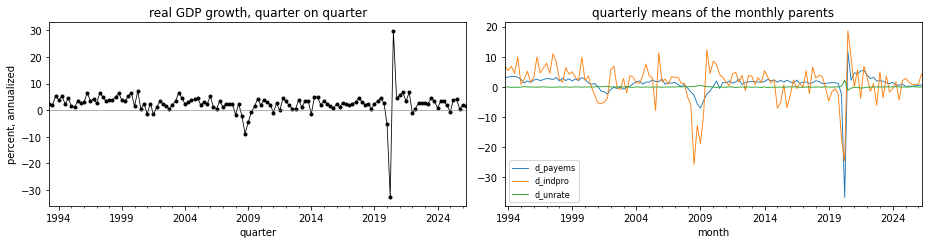

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
g.plot(ax=axes[0], marker=".", lw=0.8, color="black"); axes[0].axhline(0, color="grey", lw=0.6); axes[0].set_ylabel("percent, annualized"); axes[0].set_title("real GDP growth, quarter on quarter")
Bridge.quarterly_means(data[parents]).plot(ax=axes[1], lw=0.9); axes[1].set_title("quarterly means of the monthly parents"); axes[1].legend(fontsize=8); plt.tight_layout(); plt.show()

## The bridge equation

`Bridge` fits, on the quarters where all three months are observed,

$$g_q = c + \boldsymbol{\gamma}' \bar{\mathbf{z}}_q + \phi\, g_{q-1} + \sigma\, \eta_q, \qquad
\bar{\mathbf{z}}_q = \frac{1}{3} \sum_{t \in q} \mathbf{z}_t,$$

the quarter's growth on the quarterly means of the monthly parents and on its
own lag, by least squares: with $\mathbf{X}$ the design matrix (constant, the
three means, the lag) over the $n$ usable quarters,
$\hat{\boldsymbol{\beta}} = (\mathbf{X}'\mathbf{X})^{-1} \mathbf{X}' \mathbf{g}$,
$\hat\sigma^2 = \mathbf{e}'\mathbf{e} / (n - 5)$,
$t_j = \hat\beta_j / (\hat\sigma \sqrt{[(\mathbf{X}'\mathbf{X})^{-1}]_{jj}})$ and
$R^2 = 1 - \mathbf{e}'\mathbf{e} / \sum_q (g_q - \bar g)^2$. Each coefficient of
$\boldsymbol{\gamma}$ is the response of annualized quarterly growth to one
point of the parent's quarterly mean. The pandemic quarters (2020Q2: $-33$
percent, 2020Q3: $+30$) dominate the fit; the same equation is estimated
without them by dropping the two quarters from the target series, the lag of
the following quarter then being the previous quarter kept in the sample. The
table sets the two estimates side by side.

In [4]:
br = Bridge(parents, lags=1).fit(g, data[parents])
print(br, "| R2", round(br.r2, 3), "| sigma", round(br.sigma, 2), "| quarters", br.n_obs)
keep = [q for q in g.index if str(q) not in ("2020Q2", "2020Q3")]
br_x = Bridge(parents, lags=1).fit(g.loc[keep], data[parents])
print("without 2020Q2-Q3 | R2", round(br_x.r2, 3), "| sigma", round(br_x.sigma, 2), "| quarters", br_x.n_obs)
pd.concat({"all quarters": br.report, "without 2020Q2-Q3": br_x.report}, axis=1).round(3)

Bridge(d_payems, d_indpro, d_unrate; lags=1), fitted | R2 0.853 | sigma 1.79 | quarters 129
without 2020Q2-Q3 | R2 0.483 | sigma 1.73 | quarters 127


all quarters         without 2020Q2-Q3       
          coefficient       t       coefficient      t
const           2.482  11.929             1.947  7.967
d_payems        0.304   2.416             0.416  2.600
d_indpro        0.146   4.484             0.139  4.138
d_unrate      -10.040  -4.903            -4.275 -1.858
g_l1           -0.225  -6.304            -0.072 -0.891

The fitted growth, $\hat g_q = g_q - \hat\sigma\, \hat\eta_q$, against the actual
series, the axis cut at $\pm 12$ percent to leave the pandemic quarters out of
the picture. The residual layer of the child is $\hat\eta_q = e_q / \hat\sigma$,
tested for independence with the Ljung-Box statistic
$Q(m) = n(n+2) \sum_{j=1}^{m} \hat\rho_j^2 / (n - j)$ on $\hat\eta_q$ and on
$\hat\eta_q^2$ and with the ARCH-LM statistic ($n R^2$ of $\hat\eta_q^2$ on its
lags), $p$-values printed for both estimates. The quarterly innovation of the
paths is drawn from a Johnson SU fitted to the residual's skewness $\gamma_1$
and kurtosis $\gamma_2$, the latter floored at $3.1 + 2\gamma_1^2$, the boundary
of the family; the cell prints the moments and the four parameters
$(\gamma, \xi, \delta, \lambda)$ of the standardized variable
$\xi + \lambda \sinh((Z - \gamma)/\delta)$.

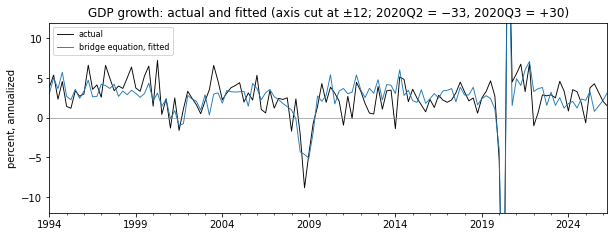

residual tests, all quarters (p-values): {'lb_z': 0.025, 'lb_z2': 0.088, 'arch_lm': 0.258}
residual tests, without 2020Q2-Q3:       {'lb_z': 0.323, 'lb_z2': 0.607, 'arch_lm': 0.767}
residual skew -0.19 kurt 3.0; Johnson SU fitted: {'gamma': 2.181, 'xi': 2.082, 'delta': 5.81, 'lambda': 5.338}


In [5]:
fitted = g.loc[br.resid.index] - br.sigma * br.resid
fig, ax = plt.subplots(figsize=(10, 3.5))
g.loc[br.resid.index].plot(ax=ax, color="black", lw=0.9, label="actual"); fitted.plot(ax=ax, color="tab:blue", lw=0.9, label="bridge equation, fitted")
ax.axhline(0, color="grey", lw=0.6); ax.set_ylabel("percent, annualized"); ax.legend(fontsize=8); ax.set_ylim(-12, 12); ax.set_title("GDP growth: actual and fitted (axis cut at ±12; 2020Q2 = −33, 2020Q3 = +30)"); plt.show()
print("residual tests, all quarters (p-values):", {k: round(v, 3) for k, v in iid_tests(br.resid.values).items()})
print("residual tests, without 2020Q2-Q3:      ", {k: round(v, 3) for k, v in iid_tests(br_x.resid.values).items()})
print("residual skew %.2f kurt %.1f; Johnson SU fitted:" % (br.resid.skew(), br.resid.kurt() + 3), {k: round(v, 3) for k, v in br.residual.items() if k in ("gamma", "xi", "delta", "lambda")})

Read the equation: with the pandemic quarters in, a point of annualized
payroll growth adds 0.3 to GDP growth, a point of industrial-production growth
0.15, and a one-point rise in the unemployment rate within the quarter takes
about 10 points off, the coefficient that the second quarter of 2020 pins
down; without those two quarters the unemployment coefficient halves and loses
its significance, and the fit is that of an ordinary bridge equation, half the
variance of a noisy quarterly series, with an innovation of 1.7 percent a
year. The residual of the trimmed equation passes the independence tests;
with the pandemic quarters in, some autocorrelation remains.

## The monthly market

The three parents are a block, filtered by the vector error-correction model
$\Delta \mathbf{z}_t = \mathbf{c} + \boldsymbol{\alpha}\boldsymbol{\beta}' \mathbf{z}_{t-1} + \boldsymbol{\Gamma}_1 \Delta \mathbf{z}_{t-1} + \boldsymbol{\eta}_t$
with the rank left to the Johansen trace test
$\mathrm{LR}(r) = -T \sum_{i > r} \ln(1 - \hat\lambda_i)$; they are stationary
growth rates and a change, every rank below three is rejected, and the block
is a VAR in levels. SPY keeps its AR(1)-GARCH. The residual layer is the
block's standardized innovations $\varepsilon_{k,t} = \hat\eta_{k,t} / \hat\sigma_k$
and SPY's GARCH residual. The pandemic months are excluded from the residual
layer's fit, as in notebook 13: payroll growth in April 2020 is a 20-sigma
innovation, and the targets and the vine are estimated on the other months
while the filters use them all.

The cell also measures the assumption the bridge makes. The quarterly
innovation $\eta_q$ is drawn independently of the monthly residual layer; its
sample correlation with the quarterly means of the monthly residuals,
$\bar\varepsilon_{k,q} = \frac{1}{3} \sum_{t \in q} \varepsilon_{k,t}$, on the
equation's quarters says what that independence leaves out: nil with the
parents, by the orthogonality of least squares once the aggregation is the
mean, and whatever the number shows with SPY.

In [6]:
exclude = ["2020-03", "2020-04", "2020-05", "2020-06"]
t = Targets.from_history(data)
t0 = time.time()
cv = CVineMarket(t, central="SPY", families="auto", dynamics={tuple(parents): "vecm", "SPY": "ar1-garch"}, exclude=exclude).fit()
print(f"fit: {time.time() - t0:.0f} s")
cv.dynamics_report
Zm = cv.dynamics.filter(data)                                  # monthly residual layer
Zq = Bridge.quarterly_means(Zm).loc[br.resid.index]           # its quarterly means, on the equation's quarters
print("correlation of the bridge residual with the quarterly means of the monthly residuals:")
print(Zq.corrwith(br.resid).round(3).to_dict())

fit: 184 s
correlation of the bridge residual with the quarterly means of the monthly residuals:
{'d_payems': -0.034, 'd_indpro': -0.037, 'd_unrate': 0.045, 'SPY': 0.28}


The targets and the vine. `fit_targets.moments` gives the mean, volatility,
skewness and kurtosis of each residual column on the retained months (the
block's volatilities are below one because $\hat\sigma_k$ was estimated on all
months, the pandemic included); `fit_targets.corr` is the correlation matrix the
calibration reproduces, payrolls and the unemployment change strongly negative;
`edges` lists the pair-copulas of the C-vine with SPY as the central node,
family, rotation or mixture, and calibrated parameters (a Gumbel with
parameter $\theta$ has upper-tail coefficient $2 - 2^{1/\theta}$).

In [7]:
print(cv.fit_targets.moments.round(2)); print(cv.fit_targets.corr.round(2)); cv.edges

          mean   vol  skew   kurt
SPY      -0.05  0.99 -0.68   4.03
d_payems  0.04  0.36  0.78   9.12
d_indpro  0.03  0.72 -0.24  11.57
d_unrate -0.04  0.43 -1.21   8.30
           SPY  d_payems  d_indpro  d_unrate
SPY       1.00     -0.02       0.0      0.03
d_payems -0.02      1.00       0.5     -0.76
d_indpro  0.00      0.50       1.0     -0.40
d_unrate  0.03     -0.76      -0.4      1.00


,tree,edge,selected family,parameters
0,1,"d_payems , SPY",clayton 180° + clayton 270°,"w=0.63, theta=(0.217, 0.487)"
1,1,"d_indpro , SPY",clayton 180° + clayton 270°,"w=0.84, theta=(0.125, 1.081)"
2,1,"d_unrate , SPY",clayton 0° + clayton 90°,"w=0.33, theta=(0.532, 0.166)"
3,2,"d_indpro , d_payems | SPY",gumbel 0°,theta=1.495
4,2,"d_unrate , d_payems | SPY",gaussian 0°,theta=-0.773
5,3,"d_unrate , d_indpro | SPY, d_payems",gumbel 270°,theta=1.022


## Paths: 24 months, eight quarters

`simulate_paths` gives the monthly paths of the parents and of SPY: the vine
draws the four residual columns per path and month, the block's recursion in
levels rebuilds the parents from the last observed rows, SPY's GARCH recursion
its returns. `Bridge.simulate` groups the 24 months by three, $Q = 8$ quarters,
averages the parents per quarter and applies the equation with the last
observed quarter as the first lag and a quarterly innovation drawn from the
fitted Johnson SU, independent across paths and quarters and of the monthly
draw:

$$\bar{\mathbf{z}}^{(s)}_q = \frac{1}{3} \sum_{t=3q-2}^{3q} \mathbf{z}^{(s)}_t, \qquad
g^{(s)}_q = \hat c + \hat{\boldsymbol{\gamma}}' \bar{\mathbf{z}}^{(s)}_q + \hat\phi\, g^{(s)}_{q-1} + \hat\sigma\, \eta^{(s)}_q, \quad g^{(s)}_0 = g_T.$$

`growth_to_level` cumulates the growth into the level of output,
$Y^{(s)}_q = 100 \exp\big( \frac{1}{400} \sum_{j \le q} g^{(s)}_j \big)$, and
`recession_probability` counts the paths with $k = 2$ consecutive negative
quarters within the horizon, $\frac{1}{S} \sum_s \mathbf{1}\{\exists q : g^{(s)}_{q-1} < 0,\ g^{(s)}_q < 0\}$,
and the share of paths whose first such run ends in each quarter. The fans
show the quantiles across paths of growth and level by quarter; the table
gives the 5, 50 and 95 percent quantiles of both.

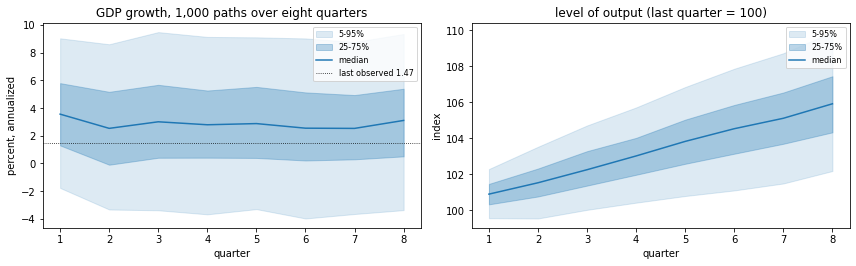

probability of two consecutive negative quarters within two years: 0.172; by quarter of the second negative one: [0.    0.033 0.031 0.017 0.026 0.021 0.028 0.016]


,growth 5%,growth 50%,growth 95%,level 5%,level 50%,level 95%
1,-1.77,3.57,9.04,99.56,100.90,102.29
2,-3.32,2.54,8.62,99.54,101.53,103.52
3,-3.38,3.01,9.49,100.02,102.25,104.71
4,-3.67,2.80,9.15,100.42,103.02,105.71
5,-3.30,2.88,9.11,100.79,103.82,106.84
6,-3.97,2.55,9.04,101.10,104.53,107.86
7,-3.65,2.54,8.78,101.49,105.11,108.72
8,-3.37,3.11,9.35,102.18,105.91,109.89


In [8]:
P = cv.simulate_paths(1000, 24, seed=1)
G = br.simulate(P, g.values, seed=1)
L = growth_to_level(G)
def fan(ax, X, last, title, ylabel="percent, annualized", x0=1):
    q = np.quantile(X, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0); h = X.shape[1]; xs = range(x0, x0 + h)
    ax.fill_between(xs, q[0], q[4], color="tab:blue", alpha=0.15, label="5-95%"); ax.fill_between(xs, q[1], q[3], color="tab:blue", alpha=0.3, label="25-75%")
    ax.plot(xs, q[2], color="tab:blue", label="median")
    if last is not None: ax.axhline(last, color="black", lw=0.8, ls=":", label=f"last observed {last:.2f}")
    ax.set_xlabel("quarter"); ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(fontsize=8)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
fan(axes[0], G.array[:, :, 0], g.iloc[-1], "GDP growth, 1,000 paths over eight quarters"); fan(axes[1], L, None, "level of output (last quarter = 100)", "index")
plt.tight_layout(); plt.show()
p_rec, by_q = recession_probability(G, k=2)
print(f"probability of two consecutive negative quarters within two years: {p_rec:.3f}; by quarter of the second negative one:", by_q.round(3))
pd.DataFrame({"growth 5%": np.quantile(G.array[:, :, 0], 0.05, axis=0), "growth 50%": np.quantile(G.array[:, :, 0], 0.5, axis=0), "growth 95%": np.quantile(G.array[:, :, 0], 0.95, axis=0),
              "level 5%": np.quantile(L, 0.05, axis=0), "level 50%": np.quantile(L, 0.5, axis=0), "level 95%": np.quantile(L, 0.95, axis=0)}, index=range(1, 9)).round(2)

## A payroll scenario

Payroll growth is lowered by 1.5 points (annualized) for six months. The
block's innovations are correlated, payrolls with the unemployment change at
$-0.76$ and with industrial production at $+0.5$, so a shock to payrolls alone
would contradict the dependence the sample shows: the scenario shifts each
innovation of the block by its linear projection on the payroll shock. With
$\delta = -1.5 / \hat\sigma_{pay}$ the shock in the payroll innovation's units,
and $\rho_{j, pay}$ and $v_j$ the residual layer's correlations and volatilities
(the targets of the vine),

$$\tilde\varepsilon^{(s)}_{j,t} = \varepsilon^{(s)}_{j,t} + b_j\, \delta, \quad t = 1, \dots, 6, \qquad
b_j = \frac{\mathrm{cov}(\varepsilon_j, \varepsilon_{pay})}{\mathrm{var}(\varepsilon_{pay})} = \rho_{j, pay}\, \frac{v_j}{v_{pay}}, \quad b_{pay} = 1,$$

a labour-market shock rather than a payroll shock. Everything else is drawn as
before, the same residual matrix `E` being pushed through the models in both
cases and the same quarterly innovations $\eta^{(s)}_q$ (same seed) used for
both bridges, so the difference between the two is the shock alone. GDP
answers through the equation, and over time through the block's dynamics. The
first table follows the medians of the three parents at months 1, 3, 6, 12 and
24; the second the medians of quarterly growth and of the level, and the
cumulative probability of two negative quarters by each quarter,
$\sum_{q' \le q} \Pr(\text{first run ends in } q')$.

In [9]:
cols = cv.dynamics.columns
E = cv.simulate(1000 * 24, seed=1, accept=False).loc[:, cols].values.reshape(1000, 24, len(cols))
base = cv.dynamics.unfilter(E)
blk = cv.dynamics.models[tuple(parents)]; sigma_pay = blk.sigma[blk.columns.index("d_payems")]
delta = -1.5 / sigma_pay                                       # the payroll shock in the innovation's units
C, V = cv.fit_targets.corr, cv.fit_targets.moments["vol"]
beta = {c: C.loc[c, "d_payems"] * V[c] / V["d_payems"] for c in parents}   # projection of each block innovation on the payroll one
print("projection coefficients:", {k: round(v, 3) for k, v in beta.items()})
Es = E.copy()
for c in parents:
    Es[:, :6, cols.index(c)] += beta[c] * delta
shock = cv.dynamics.unfilter(Es)
Pb = Paths(base, cols, layer="mixed"); Ps = Paths(shock, cols, layer="mixed")
Gb = br.simulate(Pb, g.values, seed=1); Gs = br.simulate(Ps, g.values, seed=1)
med = lambda A, c: np.median(A[:, :, cols.index(c)], axis=0)
tab = pd.DataFrame({"payroll growth, median (baseline)": med(base, "d_payems")[[0, 2, 5, 11, 23]], "payroll growth, median (scenario)": med(shock, "d_payems")[[0, 2, 5, 11, 23]],
                    "IP growth, median (baseline)": med(base, "d_indpro")[[0, 2, 5, 11, 23]], "IP growth, median (scenario)": med(shock, "d_indpro")[[0, 2, 5, 11, 23]],
                    "unemployment change, median (baseline)": med(base, "d_unrate")[[0, 2, 5, 11, 23]], "unemployment change, median (scenario)": med(shock, "d_unrate")[[0, 2, 5, 11, 23]]}, index=[1, 3, 6, 12, 24]).round(2)
print(tab.T)
pd.set_option("display.width", 200)
pd.DataFrame({"GDP growth, median (baseline)": np.median(Gb.array[:, :, 0], axis=0), "GDP growth, median (scenario)": np.median(Gs.array[:, :, 0], axis=0),
              "level, median (baseline)": np.median(growth_to_level(Gb), axis=0), "level, median (scenario)": np.median(growth_to_level(Gs), axis=0),
              "P(two negative quarters by then), baseline": np.cumsum(recession_probability(Gb)[1]), "P(two negative quarters by then), scenario": np.cumsum(recession_probability(Gs)[1])}, index=range(1, 9)).round(3).T

projection coefficients: {'d_payems': 1.0, 'd_indpro': 0.985, 'd_unrate': -0.907}
                                          1     3     6     12    24
payroll growth, median (baseline)       2.42  1.31  1.45  1.45  1.46
payroll growth, median (scenario)       0.92 -0.14  0.04  1.45  1.46
IP growth, median (baseline)            3.87  1.20  2.04  2.14  1.67
IP growth, median (scenario)            1.88 -0.69  0.20  2.14  1.67
unemployment change, median (baseline) -0.06 -0.02 -0.01 -0.02 -0.02
unemployment change, median (scenario)  0.02  0.06  0.07 -0.02 -0.02


,1,2,3,4,5,6,7,8
"GDP growth, median (baseline)",3.566,2.539,3.013,2.798,2.884,2.551,2.536,3.111
"GDP growth, median (scenario)",1.939,1.425,3.396,2.699,2.907,2.546,2.537,3.111
"level, median (baseline)",100.895,101.526,102.251,103.015,103.823,104.527,105.106,105.910
"level, median (scenario)",100.486,100.833,101.650,102.384,103.193,103.892,104.468,105.267
"P(two negative quarters by then), baseline",0.000,0.033,0.064,0.081,0.107,0.128,0.156,0.172
"P(two negative quarters by then), scenario",0.000,0.078,0.106,0.121,0.147,0.165,0.192,0.208


## With and without the pandemic quarters in the equation

The two estimates of the bridge equation applied to the same monthly paths and
the same quarterly innovation draws (same seed), so that the difference is the
coefficients alone. The unemployment coefficient pinned down by 2020Q2 makes
the growth paths more sensitive to the unemployment innovations; the
innovation scale is about the same. The table compares the median and the 5
and 95 percent quantiles of growth at the fourth quarter, the pooled standard
deviation of growth over paths and quarters, and the probability of two
negative quarters within two years. The quantiles are those of $g^{(s)}_4$ across the $S = 1{,}000$ paths, the pooled standard deviation is over all $S \times 8$ values, and the probability is $\frac{1}{S} \sum_s \mathbf{1}\{\exists q : g^{(s)}_{q-1} < 0,\ g^{(s)}_q < 0\}$.

In [10]:
G_x = br_x.simulate(P, g.values, seed=1)
pd.DataFrame({"all quarters": [np.median(G.array[:, 3, 0]), np.quantile(G.array[:, 3, 0], 0.05), np.quantile(G.array[:, 3, 0], 0.95), G.array[:, :, 0].std(), recession_probability(G)[0]],
              "without 2020Q2-Q3": [np.median(G_x.array[:, 3, 0]), np.quantile(G_x.array[:, 3, 0], 0.05), np.quantile(G_x.array[:, 3, 0], 0.95), G_x.array[:, :, 0].std(), recession_probability(G_x)[0]]},
             index=["growth median, quarter 4", "growth 5%, quarter 4", "growth 95%, quarter 4", "growth sd, pooled", "P(two negative quarters in two years)"]).round(3)

,all quarters,without 2020Q2-Q3
"growth median, quarter 4",2.798,2.773
"growth 5%, quarter 4",-3.673,-2.457
"growth 95%, quarter 4",9.146,7.849
"growth sd, pooled",3.878,3.110
P(two negative quarters in two years),0.172,0.155


## Save

`cv.save` writes the monthly market to JSON (targets, Johnson SU parameters,
edges, dynamics with the block's last state and the excluded months) and
`Bridge.to_dict` the equation (coefficients, $t$-statistics, $\hat\sigma$, the
Johnson SU of the innovation); the last line reloads both and bridges three
paths of six months into two quarters as a check.

In [11]:
import json
cv.save("gdp_market.json")
with open("gdp_bridge.json", "w") as f:
    json.dump(br.to_dict(), f)
Bridge.from_dict(json.load(open("gdp_bridge.json"))).simulate(CVineMarket.load("gdp_market.json").simulate_paths(3, 6, seed=2), g.values, seed=3)

Paths(n_paths=3, horizon=2, assets=1, growth)

## Where to go next

Any quarterly series bridges the same way: corporate earnings on monthly
indicators, a quarterly house-price index on monthly rates and income. The
next step is the feedback from output to the monthly variables, which this
construction does not model.